In [1]:
from arch import arch_model
from series_analysis import PriceAnalysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


/Users/petterollinen/venvs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
analysis = PriceAnalysis.from_csv("spiff_data-2.csv").clean()
prices = analysis.prices
gap_table = analysis.gap_table()
internal_gaps = gap_table[gap_table["gap_type"] == "internal"].copy()
log_return_data=analysis.log_returns

In [3]:
internal_gaps

,series,start,end,length,gap_type
0,guitars,399,448,50,internal
2,gurkor,199,248,50,internal
4,slingshots,599,648,50,internal
6,stocks,799,848,50,internal
8,sugar,999,1048,50,internal
10,tranquillity,1399,1448,50,internal
12,water,1199,1248,50,internal


## Gap Interpolation Methods

All methods share the same fundamental pipeline.

**Shared pipeline**

1. **Log-price anchoring** — The gap has a known left endpoint $P_\text{left}$ (last observed price before the gap) and right endpoint $P_\text{right}$ (first observed after). All modelling is done in log-price space, equivalently on log-returns $r_t = \log(P_t / P_{t-1})$, which are approximately stationary.

2. **Two-sided calibration** — Parameters are estimated from a `calibration_window`-day window of returns *before* the gap and a `look_forward`-day window *after*. Using both sides prevents the fitted distribution from being biased by conditions on just one side of the gap.

3. **Monte Carlo paths** — 1 000 sequences of log-return increments are simulated, each of length equal to the gap.

4. **Bridge correction** — Raw simulated paths almost certainly don't end at $P_\text{right}$. Every path's increments are additively shifted so they sum exactly to $\log(P_\text{right}/P_\text{left})$, pinning both endpoints on every single path. How the correction is distributed across steps differs: *uniform* when steps are i.i.d., *variance-weighted* when a heteroskedastic variance schedule is available.

5. **Back to price space** — $\hat{P}_t = \exp\!\left(\log P_\text{left} + \sum_{s=1}^{t} \hat{r}_s\right)$.

---

### Random Walk (GBM baseline)

The simplest model: log-returns are i.i.d. Gaussian, $r_t \sim \mathcal{N}(\mu, \sigma^2)$, with $\mu$ and $\sigma$ estimated from the pooled calibration window. This is a discretised Geometric Brownian Motion. Bridge correction is uniform because every step is drawn from the same distribution. Serves as the performance baseline for all other methods.

In [4]:
def random_walk(
    price_series: pd.Series,
    start_day,
    end_day,
    calibration_window: int = 60,   # used on BOTH sides
    n_simulations: int = 1000,
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap in a price series with a Geometric Brownian Motion
    random walk and return uncertainty measures.

    Parameters
    ----------
    price_series : pd.Series
        Observed prices with a sortable index (DatetimeIndex or numeric).
        Values inside [start_day, end_day] are treated as missing.
    start_day :
        First index label of the gap (inclusive). The anchor price is the
        last observed value *before* this label.
    end_day :
        Last index label of the gap (inclusive). If data exists after this
        label, a Brownian bridge is used to pin paths to that value.
        Number of post-gap observations to include when calibrating vol/drift.
    n_simulations : int, default 1000
        Monte Carlo paths to simulate.
    calibration_window : int, default 60
        Number of pre-gap observations to include when calibrating vol/drift.
    random_seed : int or None
        Pass an integer for reproducible results.

    Returns
    -------
    dict with keys:
        gap_index, median, mean, std, percentiles (DataFrame),
        simulations, full_series, drift, volatility, method
    """
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()

    # ── 1. Anchor and target prices ───────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations found before start_day.")

    anchor_price = float(pre.iloc[-1])
    target_price = float(post.iloc[0]) if len(post) > 0 else None

    # ── 2. Calibrate drift and volatility from surrounding log-returns ────
    cal_pre  = pre.iloc[-calibration_window:]
    cal_post = post.iloc[:calibration_window]   # same window, other side
    cal      = pd.concat([cal_pre, cal_post]).sort_index()
    log_rets = np.log(cal / cal.shift(1)).dropna()

    if len(log_rets) < 5:
        raise ValueError(
            f"Only {len(log_rets)} log-returns available for calibration (need ≥ 5). "
            "Increase calibration_window."
        )

    drift      = float(log_rets.mean())
    volatility = float(log_rets.std())

    # ── 3. Build the gap index ────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length — check start_day / end_day.")

    # ── 4. Simulate GBM paths  (n_sims × gap_len) ────────────────────────
    # S_t = S_0 · exp( (µ - ½σ²)t + σ·W_t )
    steps       = np.arange(1, gap_len + 1)
    shocks      = rng.standard_normal((n_simulations, gap_len))
    cum_shocks  = np.cumsum(shocks, axis=1)
    log_paths   = (drift - 0.5 * volatility**2) * steps + volatility * cum_shocks
    paths       = anchor_price * np.exp(log_paths)

    # ── 5. Brownian bridge: pin paths to target price if available ────────
    if target_price is not None:
        log_correction = (
            np.log(target_price / paths[:, -1])[:, np.newaxis]
            * steps[np.newaxis, :] / gap_len
        )
        paths = paths * np.exp(log_correction)

    # ── 6. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T,
        index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    # ── 7. Full series with gap filled by median path ─────────────────────
    outside = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "random_walk_gbm",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "drift":       drift,
        "volatility":  volatility,
    }

### GARCH Bridge

Extends the random walk by modelling **volatility clustering** — the empirical regularity that large moves tend to follow large moves. A GARCH(1,1) model is fit separately on the pre-gap returns (forward direction) and on the sign-reversed, time-reversed post-gap returns (backward direction), producing two horizon-length conditional variance forecasts. These are blended linearly across the gap to form a heteroskedastic step-variance schedule: more certain near the endpoints where the GARCH state is informed by data, less certain toward the centre.

Innovations are drawn from a **Student-t** distribution rather than Gaussian, capturing the fat tails common in commodity and financial returns. The bridge correction is variance-weighted — steps with higher predicted variance absorb a proportionally larger share of the endpoint adjustment, which is the appropriate weighting when the increments are not i.i.d.

In [5]:
def garch_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap using a two-sided Student-t GARCH(1,1) bridge.

    GARCH(1,1) with Student-t innovations is fit on pre-gap returns (forward)
    and negated/time-reversed post-gap returns (backward).  The two resulting
    horizon-length variance schedules are blended linearly across the gap.
    Paths are drawn with Student-t innovations scaled by those heteroskedastic
    step variances, then individually corrected so every path exactly hits both
    the left and right log-price endpoints (Doob h-transform style).
    """
    import warnings as _warnings

    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()

    # ── 1. Endpoints in log space ─────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("Two-sided GARCH bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Log-return calibration windows ────────────────────────────────
    def log_ret(s: pd.Series) -> pd.Series:
        return np.log(s / s.shift(1)).dropna()

    pre_returns  = log_ret(pre.iloc[-calibration_window:])
    post_returns = log_ret(post.iloc[:calibration_window])

    if len(pre_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} pre-gap returns, got {len(pre_returns)}.")
    if len(post_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} post-gap returns, got {len(post_returns)}.")

    # ── 3. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length — check start_day / end_day.")

    horizon = gap_len + 1   # bridge needs one extra step

    # ── 4. Fit GARCH(1,1)-t → horizon conditional variance forecast ───────
    def fit_garch_variances(returns: pd.Series, h: int, reverse: bool = False):
        clean = returns.dropna().astype(float)
        if reverse:
            clean = -clean.iloc[::-1]      # negate + time-reverse for backward pass
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            model  = arch_model(clean * 100, mean="Zero", vol="GARCH", p=1, q=1,
                                dist="StudentsT", rescale=False)
            result = model.fit(disp="off", show_warning=False)
            fc     = result.forecast(horizon=h, reindex=False)
        variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4
        if not np.isfinite(variances).all() or np.any(variances <= 0):
            raise ValueError("GARCH produced non-finite variance forecast.")
        nu = float(result.params.get("nu", np.nan))
        return variances, nu

    pre_vars,      nu_pre  = fit_garch_variances(pre_returns,  horizon, reverse=False)
    post_vars_bwd, nu_post = fit_garch_variances(post_returns, horizon, reverse=True)
    post_vars = post_vars_bwd[::-1]    # flip to align with gap direction

    # ── 5. Blend variance schedules ───────────────────────────────────────
    lw            = np.linspace(1.0, 0.0, horizon)
    step_variances = np.maximum(lw * pre_vars + (1 - lw) * post_vars, 1e-12)

    # Use the fatter-tailed (smaller) valid ν — conservative choice
    nu_valid = [nu for nu in (nu_pre, nu_post) if np.isfinite(nu) and nu > 2.05]
    if not nu_valid:
        raise ValueError(f"Invalid degrees of freedom from GARCH fits: {nu_pre=}, {nu_post=}.")
    bridge_nu = float(min(nu_valid))

    # ── 6. Conditional Student-t bridge paths ─────────────────────────────
    # Standardised t innovations (unit variance) scaled by sqrt(step_var),
    # then every path's increments are shifted to sum to right_log - left_log,
    # weighted by variance share — pins both endpoints on every path.
    total_move     = right_log - left_log
    total_variance = float(step_variances.sum())

    dof = bridge_nu if (np.isfinite(bridge_nu) and bridge_nu > 2.05) else 8.0
    z   = rng.standard_t(dof, size=(n_simulations, horizon)) * np.sqrt((dof - 2.0) / dof)

    raw_inc = z * np.sqrt(step_variances)[None, :]
    raw_sum = raw_inc.sum(axis=1)
    weights = step_variances / total_variance
    adj_inc = raw_inc + (total_move - raw_sum)[:, None] * weights[None, :]

    log_paths = left_log + np.cumsum(adj_inc, axis=1)[:, :-1]   # (n_sims, gap_len)
    paths     = np.exp(log_paths)

    # ── 7. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "garch_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "nu_pre":      nu_pre,
        "nu_post":     nu_post,
        "bridge_nu":   bridge_nu,
    }


### ARIMA Bridge

While GARCH targets variance dynamics, ARIMA targets **serial autocorrelation** in the return level — momentum or mean-reversion. An ARMA(1,1) is fit on the calibration returns using the same two-sided approach, and its multi-step forecast variance is used as the heteroskedastic step-variance schedule. Innovations are Gaussian. The bridge correction is variance-weighted as with GARCH.

In practice ARIMA and GARCH bridge deliver similar accuracy. ARIMA tends to be marginally better when returns show return persistence; GARCH when they exhibit volatility clustering.

In [6]:
def arima_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    order: tuple = (1, 0, 1),
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap using a two-sided ARIMA bridge with Gaussian innovations.

    ARIMA(p,d,q) is fit on pre-gap log-returns (forward) and negated/time-reversed
    post-gap log-returns (backward).  The per-step forecast variances from each
    side are blended linearly across the gap to form a heteroskedastic variance
    schedule.  Paths are drawn with Gaussian innovations scaled by those variances,
    then individually corrected so every path exactly hits both log-price endpoints.

    Parameters
    ----------
    order : (p, d, q)
        ARIMA order passed to statsmodels.  Default (1, 0, 1) fits an ARMA(1,1)
        on log-returns (stationary, so d=0 is appropriate).
    """
    import warnings as _warnings
    from statsmodels.tsa.arima.model import ARIMA as _ARIMA

    MIN_OBS = 10
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()

    # ── 1. Endpoints in log space ─────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("Two-sided ARIMA bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Log-return calibration windows ────────────────────────────────
    def log_ret(s: pd.Series) -> pd.Series:
        return np.log(s / s.shift(1)).dropna()

    pre_returns  = log_ret(pre.iloc[-calibration_window:])
    post_returns = log_ret(post.iloc[:calibration_window])

    if len(pre_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} pre-gap returns, got {len(pre_returns)}.")
    if len(post_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} post-gap returns, got {len(post_returns)}.")

    # ── 3. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length — check start_day / end_day.")

    horizon = gap_len + 1

    # ── 4. Fit ARIMA → per-step forecast variance schedule ───────────────
    def fit_arima_variances(returns: pd.Series, h: int, reverse: bool = False) -> np.ndarray:
        clean = returns.dropna().astype(float)
        if reverse:
            clean = -clean.iloc[::-1]
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            result = _ARIMA(clean, order=order).fit()
            fc     = result.get_forecast(steps=h)
            step_vars = fc.summary_frame()["mean_se"].values ** 2
        if not np.isfinite(step_vars).all() or np.any(step_vars <= 0):
            step_vars = np.full(h, float(result.resid.var()))
        return np.maximum(step_vars, 1e-12)

    pre_vars      = fit_arima_variances(pre_returns,  horizon, reverse=False)
    post_vars_bwd = fit_arima_variances(post_returns, horizon, reverse=True)
    post_vars     = post_vars_bwd[::-1]    # align to gap direction

    # ── 5. Blend variance schedules ───────────────────────────────────────
    lw             = np.linspace(1.0, 0.0, horizon)
    step_variances = np.maximum(lw * pre_vars + (1 - lw) * post_vars, 1e-12)

    # ── 6. Conditional Gaussian bridge paths ─────────────────────────────
    total_move     = right_log - left_log
    total_variance = float(step_variances.sum())

    z       = rng.standard_normal((n_simulations, horizon))
    raw_inc = z * np.sqrt(step_variances)[None, :]
    raw_sum = raw_inc.sum(axis=1)
    weights = step_variances / total_variance
    adj_inc = raw_inc + (total_move - raw_sum)[:, None] * weights[None, :]

    log_paths = left_log + np.cumsum(adj_inc, axis=1)[:, :-1]
    paths     = np.exp(log_paths)

    # ── 7. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "arima_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "order":       order,
    }


### Cross-Series Methods

The next two methods exploit the fact that **companion series are fully observed during the gap**. OLS regression is fit on pre-gap log-returns:

$$r_{\text{target},\,t} = \beta_0 + \beta_1 r_{1,t} + \cdots + \beta_k r_{k,t} + \varepsilon_t$$

This gives a deterministic predicted return path $\hat{r}_t$ during the gap, using the observed companion returns. Only the residual $\varepsilon_t$ needs to be simulated — which is far less uncertain than the full return. Bridge correction is applied to the residuals alone.

The gain is large when companions correlate with the target (guitars, gurkor, water, slingshots: ~30–39% MAPE reduction over single-series methods) and absent or harmful when they do not (stocks).

#### Cross-Series OLS

The residuals are modelled as i.i.d. $\mathcal{N}(0,\,\hat{\sigma}^2_\varepsilon)$, where $\hat{\sigma}^2_\varepsilon$ is the in-sample OLS residual variance. Bridge correction is uniform across steps.

In [7]:
def cross_series_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    prices_df: pd.DataFrame,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap using cross-series OLS regression + conditional bridge.

    OLS is fit on pre-gap log-returns: r_target ~ r_companions.  During the gap,
    companion returns are fully observed and provide a deterministic predicted
    return path r_hat_t = beta @ companions_t.  Residual uncertainty is sampled
    from N(0, sigma_resid^2) and the residuals are bridge-corrected so every
    path exactly hits both log-price endpoints.

    The method degrades gracefully to a pure bridge when R² is low (wide residuals
    dominate), and captures cross-series information when correlations are high.

    Parameters
    ----------
    prices_df : pd.DataFrame
        Full prices for all series (including the target).  Companions are all
        columns other than price_series.name that have no missing data during
        the gap.
    """
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()
    target = series.name

    # ── 1. Endpoints ──────────────────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("Cross-series bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length.")

    # ── 3. Log-returns for all series ─────────────────────────────────────
    all_lr = np.log(prices_df / prices_df.shift(1))

    # Keep companions that have complete returns during the gap
    candidates   = [c for c in prices_df.columns if c != target]
    gap_lr       = all_lr.loc[(all_lr.index >= start_day) & (all_lr.index <= end_day), candidates]
    companions   = gap_lr.dropna(axis=1).columns.tolist()

    if not companions:
        raise ValueError("No companion series with complete data during the gap.")

    # ── 4. OLS calibration on pre-gap window ─────────────────────────────
    cal_lr = (
        all_lr.loc[all_lr.index < start_day, [target] + companions]
        .dropna()
        .iloc[-calibration_window:]
    )

    if len(cal_lr) < max(10, len(companions) + 2):
        raise ValueError(f"Too few calibration observations ({len(cal_lr)}).")

    y   = cal_lr[target].values
    X   = np.column_stack([np.ones(len(y)), cal_lr[companions].values])
    betas, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    resid       = y - X @ betas
    sigma_resid = float(np.std(resid, ddof=len(betas)))
    r_sq        = float(1 - np.var(resid) / np.var(y))

    if not np.isfinite(sigma_resid) or sigma_resid <= 0:
        sigma_resid = float(np.std(resid))

    # ── 5. Predicted returns during the gap from companions ───────────────
    X_gap = np.column_stack([np.ones(gap_len), gap_lr[companions].values])
    r_hat = X_gap @ betas   # (gap_len,) deterministic log-return signal

    # ── 6. Bridge-corrected residual paths ────────────────────────────────
    # Each path: log_price_t = left_log + cumsum(r_hat + epsilon_t)
    # Correction forces sum(r_hat + epsilon) = right_log - left_log on every path.
    residual_target = (right_log - left_log) - float(r_hat.sum())

    epsilon = rng.standard_normal((n_simulations, gap_len)) * sigma_resid
    adj_eps = epsilon + (residual_target - epsilon.sum(axis=1, keepdims=True)) / gap_len

    log_paths = left_log + np.cumsum(r_hat[None, :] + adj_eps, axis=1)
    paths     = np.exp(log_paths)

    # ── 7. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "cross_series_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "companions":  companions,
        "r_squared":   r_sq,
        "sigma_resid": sigma_resid,
        "betas":       dict(zip(["intercept"] + companions, betas)),
    }


#### Cross-Series + GARCH

Extends the OLS bridge by fitting a **GARCH(1,1)-t on the OLS residuals** using the same two-sided approach as the pure GARCH bridge. The idiosyncratic residuals $\varepsilon_t$ can themselves exhibit volatility clustering even after the companion signal is removed. The blended GARCH variance schedule replaces the constant $\hat{\sigma}^2_\varepsilon$, giving heteroskedastic residual uncertainty. This is the best-performing single model across most series.

In [8]:
def cross_garch_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    prices_df: pd.DataFrame,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Factor model with GARCH(1,1)-t errors: cross-series OLS signal + GARCH residual bridge.

    Step 1 – OLS: r_target = r_hat (companions) + epsilon, fit on pre-gap window.
    Step 2 – GARCH: fit GARCH(1,1)-t on the pre-gap OLS *residuals* (forward) and
              negated/reversed post-gap residuals (backward, using the same betas).
              Blend the two variance schedules linearly across the gap.
    Step 3 – Bridge: draw Student-t innovations scaled by the blended schedule,
              correct every path so its residuals sum to
              (right_log - left_log) - sum(r_hat), then add the companion signal.

    The OLS signal carries directional cross-series information; the GARCH schedule
    captures volatility clustering in the idiosyncratic residuals that plain OLS misses.
    """
    import warnings as _warnings

    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()
    target = series.name

    # ── 1. Endpoints ──────────────────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("cross_garch_bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length.")

    horizon = gap_len + 1

    # ── 3. Log-returns + companion selection ─────────────────────────────
    all_lr     = np.log(prices_df / prices_df.shift(1))
    candidates = [c for c in prices_df.columns if c != target]
    gap_lr     = all_lr.loc[(all_lr.index >= start_day) & (all_lr.index <= end_day), candidates]
    companions = gap_lr.dropna(axis=1).columns.tolist()

    if not companions:
        raise ValueError("No companion series with complete data during the gap.")

    # ── 4. OLS on pre-gap window → betas + residuals ──────────────────────
    cal_lr = (
        all_lr.loc[all_lr.index < start_day, [target] + companions]
        .dropna()
        .iloc[-calibration_window:]
    )
    if len(cal_lr) < max(MIN_OBS, len(companions) + 2):
        raise ValueError(f"Too few calibration observations ({len(cal_lr)}).")

    y_cal  = cal_lr[target].values
    X_cal  = np.column_stack([np.ones(len(y_cal)), cal_lr[companions].values])
    betas, _, _, _ = np.linalg.lstsq(X_cal, y_cal, rcond=None)
    r_sq   = float(1 - np.var(y_cal - X_cal @ betas) / np.var(y_cal))

    pre_resid = pd.Series(y_cal - X_cal @ betas, index=cal_lr.index)

    # Post-gap residuals use the same betas (no re-fit on small post-gap sample)
    post_lr = (
        all_lr.loc[all_lr.index > end_day, [target] + companions]
        .dropna()
        .iloc[:calibration_window]
    )
    if len(post_lr) >= MIN_OBS:
        y_post     = post_lr[target].values
        X_post     = np.column_stack([np.ones(len(y_post)), post_lr[companions].values])
        post_resid = pd.Series(y_post - X_post @ betas, index=post_lr.index)
    else:
        post_resid = pre_resid

    # ── 5. GARCH(1,1)-t on OLS residuals → variance schedule ─────────────
    def fit_garch_variances(resid: pd.Series, h: int, reverse: bool = False):
        clean = resid.dropna().astype(float)
        if reverse:
            clean = -clean.iloc[::-1]
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            model  = arch_model(clean * 100, mean="Zero", vol="GARCH", p=1, q=1,
                                dist="StudentsT", rescale=False)
            result = model.fit(disp="off", show_warning=False)
            fc     = result.forecast(horizon=h, reindex=False)
        variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4
        if not np.isfinite(variances).all() or np.any(variances <= 0):
            raise ValueError("GARCH produced non-finite variance forecast.")
        nu = float(result.params.get("nu", np.nan))
        return variances, nu

    pre_vars,      nu_pre  = fit_garch_variances(pre_resid,  horizon, reverse=False)
    post_vars_bwd, nu_post = fit_garch_variances(post_resid, horizon, reverse=True)
    post_vars = post_vars_bwd[::-1]

    lw             = np.linspace(1.0, 0.0, horizon)
    step_variances = np.maximum(lw * pre_vars + (1 - lw) * post_vars, 1e-12)

    nu_valid  = [nu for nu in (nu_pre, nu_post) if np.isfinite(nu) and nu > 2.05]
    if not nu_valid:
        raise ValueError(f"Invalid GARCH degrees of freedom: {nu_pre=}, {nu_post=}.")
    bridge_nu = float(min(nu_valid))

    # ── 6. Companion signal during the gap ────────────────────────────────
    X_gap = np.column_stack([np.ones(gap_len), gap_lr[companions].values])
    r_hat = X_gap @ betas   # (gap_len,) deterministic log-return prediction

    # ── 7. Conditional Student-t bridge on residuals ──────────────────────
    # Residuals must sum to: (right_log - left_log) - sum(r_hat)
    resid_target   = (right_log - left_log) - float(r_hat.sum())
    total_variance = float(step_variances.sum())

    dof = bridge_nu if (np.isfinite(bridge_nu) and bridge_nu > 2.05) else 8.0
    z   = rng.standard_t(dof, size=(n_simulations, horizon)) * np.sqrt((dof - 2.0) / dof)

    raw_inc = z * np.sqrt(step_variances)[None, :]
    raw_sum = raw_inc.sum(axis=1)
    weights = step_variances / total_variance
    adj_inc = raw_inc + (resid_target - raw_sum)[:, None] * weights[None, :]

    # Combine signal + bridge-corrected residuals over the gap_len steps
    combined = r_hat[None, :] + adj_inc[:, :-1]   # (n_sims, gap_len)
    log_paths = left_log + np.cumsum(combined, axis=1)
    paths     = np.exp(log_paths)

    # ── 8. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "cross_garch_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "companions":  companions,
        "r_squared":   r_sq,
        "nu_pre":      nu_pre,
        "nu_post":     nu_post,
        "bridge_nu":   bridge_nu,
        "betas":       dict(zip(["intercept"] + companions, betas)),
    }


### Bootstrap Bridge

A non-parametric alternative to the random walk. Instead of fitting a parametric distribution to calibration returns and sampling from it, the observed calibration returns from both windows are **pooled and resampled with replacement**. This preserves the actual tail shape, skewness, and any multi-modality without any distributional assumption. Bridge correction is uniform, as in the random walk, since each resampled step is i.i.d. from the pool.

In practice the bootstrap performs similarly to the random walk — the series do not show strong enough non-Gaussianity in the calibration windows for the distributional flexibility to pay off over GBM.

In [9]:
def bootstrap_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap by resampling empirical log-returns + bridge correction.

    Log-returns from the pre- and post-gap calibration windows are pooled.
    Each simulated path draws gap_len increments with replacement from this pool,
    then receives a uniform additive correction so the path hits both log-price
    endpoints exactly.  No parametric distributional assumption is made — the
    empirical tail shape, skewness, and any multi-modality are preserved.
    """
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()

    # ── 1. Endpoints in log space ─────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("Bootstrap bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Pool empirical log-returns from both calibration windows ───────
    def log_ret(s: pd.Series) -> np.ndarray:
        return np.log(s / s.shift(1)).dropna().values

    pool = np.concatenate([
        log_ret(pre.iloc[-calibration_window:]),
        log_ret(post.iloc[:calibration_window]),
    ])
    pool = pool[np.isfinite(pool)]

    if len(pool) < 5:
        raise ValueError(f"Only {len(pool)} finite log-returns in pool (need ≥ 5).")

    # ── 3. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length — check start_day / end_day.")

    # ── 4. Resample increments ────────────────────────────────────────────
    idx     = rng.integers(0, len(pool), size=(n_simulations, gap_len))
    raw_inc = pool[idx]   # (n_sims, gap_len)

    # ── 5. Uniform bridge correction ──────────────────────────────────────
    # Each step gets an equal share of the gap between path-end and target.
    # Uniform weights are exact here: all steps are i.i.d. draws so no step
    # is preferentially adjusted.
    total_move = right_log - left_log
    adj_inc    = raw_inc + ((total_move - raw_inc.sum(axis=1)) / gap_len)[:, None]

    log_paths = left_log + np.cumsum(adj_inc, axis=1)
    paths     = np.exp(log_paths)

    # ── 6. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "bootstrap_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "pool_size":   len(pool),
    }

In [10]:
def plot_gap_interpolation(
    price_series: pd.Series,
    gap_start,
    gap_end,
    result: dict,
    zoom_pad: int = 60,
    title: str | None = None,
):
    x_lo = gap_start - zoom_pad
    x_hi = gap_end + zoom_pad

    pct = result.get("percentiles")
    median = result["median"]
    gap_index = result["gap_index"]

    visible_obs = price_series[(price_series.index >= x_lo) & (price_series.index <= x_hi)].dropna()
    y_candidates = [visible_obs.values, median]
    if pct is not None:
        y_candidates += [pct["p5"].values, pct["p95"].values]
    y_all = np.concatenate(y_candidates)
    y_pad = (y_all.max() - y_all.min()) * 0.05
    y_lo, y_hi = y_all.min() - y_pad, y_all.max() + y_pad

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(price_series.index, price_series.values, color="steelblue", label="Observed", zorder=3)

    if pct is not None:
        ax.fill_between(pct.index, pct["p5"], pct["p95"], alpha=0.15, color="orange", label="5–95 pct")
        ax.fill_between(pct.index, pct["p25"], pct["p75"], alpha=0.30, color="orange", label="25–75 pct")

    method_label = result.get("method", "interpolated")
    ax.plot(gap_index, median, color="orange", linewidth=2, label=f"{method_label} median")

    ax.axvspan(gap_start, gap_end, alpha=0.08, color="red", label="Gap region")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)

    name = getattr(price_series, "name", "")
    ax.set_title(title or f"{name} – {method_label} gap interpolation (zoomed)")
    ax.set_xlabel("Index")
    ax.set_ylabel("Price")
    ax.legend()
    plt.tight_layout()
    plt.show()


## Backtesting

The real gaps cannot be used to evaluate methods because the true prices during those periods are unknown. Instead, **pseudo-gaps** are cut from the observed data in parts of each series where prices are complete.

**Procedure**

1. Pick a start position at or after index 1 500 (well past any real gap, ensuring there is enough pre- and post-gap history for calibration).
2. Mask out a contiguous block of 50 days — the same length as the real gaps.
3. Run the interpolation method on the *unmasked* series. The method sees the true pre- and post-gap flanks, exactly as it would on a real gap.
4. Compare the predicted **median path** and **percentile bands** against the hidden true prices.
5. Repeat for 50 randomly chosen positions per series and average the metrics.

**Metrics**

| Metric | What it measures |
|---|---|
| MAPE (%) | Average percentage error of the median path — primary accuracy metric |
| RMSE | Absolute error in price units — sensitive to price scale |
| RMSE log | RMSE in log-price space — scale-independent, penalises proportional errors |
| Coverage 90 / 50 | Fraction of true prices falling inside the 90% / 50% prediction band — target values are 0.90 / 0.50 |
| Mean width 90% | Average width of the 90% band as a % of price — measures how tight the uncertainty is |

Coverage and band width together reveal whether a method is well-calibrated: high coverage with narrow bands is best; wide bands with the same coverage just means the method is being conservative.

---

**Limitations and overfitting pitfalls**

*Pseudo-gaps are in a different region than the real gaps.* The real gaps sit at indices 199–1448 depending on the series; backtests are constrained to start from index 1 500. If the statistical character of the series — volatility level, autocorrelation, cross-series correlation — shifts over time, the backtest region may not be representative of the actual gap region. This is unavoidable given the data, but means reported numbers are an estimate of performance in a regime that may differ from the real task.

*Method selection on the same data is overfitting.* Comparing six methods across seven series and picking the best method per series inflates apparent performance. With 50 backtests per series there is enough noise that some cross-method differences reflect sampling variation rather than true quality differences. The backtest results should be read as indicative rather than definitive rankings.

*The calibration window sweep is a hyperparameter search on the same backtest data.* Choosing the optimal window size by minimising backtest MAPE fits to that specific sample. The true optimal window for the real gaps may differ.

*Consecutive pseudo-gaps share calibration data.* The 50 drawn positions per series are not fully independent — nearby positions use overlapping calibration windows — so the effective sample size is smaller than 50 and the variance of averaged metrics is higher than it appears.

In [11]:
def backtest_interpolation(
    method,
    price_series: pd.Series,
    n_backtests: int = 50,
    gap_length: int = 50,
    start_from: int = 1500,
    **method_kwargs,
) -> pd.DataFrame:
    """
    Backtest a gap-interpolation method on pseudo gaps cut from observed data.

    For each backtest, a contiguous block of `gap_length` days is masked out
    of the series starting at or after `start_from`.  The method is called on
    the *unmasked* series (it sees the true pre- and post-gap flanks) and its
    output is compared to the true prices in the hidden block.

    Parameters
    ----------
    method : callable
        One of random_walk, garch_bridge, or any function with the same
        signature: (price_series, start_day, end_day, **kwargs) -> dict.
    price_series : pd.Series
        Full observed (clean) price series.
    n_backtests : int
        How many pseudo gaps to test.
    gap_length : int
        Number of days in each pseudo gap (default 50, matching real gaps).
    start_from : int
        Earliest index value from which pseudo gaps may start.
    **method_kwargs
        Forwarded verbatim to `method` (e.g. calibration_window, n_simulations).
        Omit random_seed to let each call vary independently.

    Returns
    -------
    pd.DataFrame
        One row per completed backtest with columns:
        start_day, end_day, rmse, mae, mape_pct, rmse_log,
        coverage_90, coverage_50, mean_width_90_pct
    """
    rng   = np.random.default_rng(method_kwargs.pop("random_seed", None))
    index = price_series.index
    n     = len(index)

    cal_win    = method_kwargs.get("calibration_window", 60)
    min_pre    = cal_win + 1          # returns needed before gap
    min_post   = cal_win + 1         # returns needed after gap

    # Collect every valid positional start index
    start_pos = next((i for i, v in enumerate(index) if v >= start_from), None)
    if start_pos is None:
        raise ValueError(f"No index values ≥ {start_from} found in series.")

    valid = [
        i for i in range(start_pos, n - gap_length - min_post)
        if i >= min_pre
        and price_series.iloc[i - 1 : i + gap_length + 1].notna().all()
    ]

    if not valid:
        raise ValueError(
            f"No valid pseudo-gap positions found from index {start_from} "
            f"(need {min_pre} pre-obs and {min_post} post-obs)."
        )

    chosen = (
        valid if n_backtests >= len(valid)
        else sorted(rng.choice(valid, size=n_backtests, replace=False).tolist())
    )

    records = []
    for pos in chosen:
        start_day  = index[pos]
        end_day    = index[pos + gap_length - 1]
        true_prices = price_series.iloc[pos : pos + gap_length].to_numpy(dtype=float)

        try:
            result = method(price_series, start_day, end_day, **method_kwargs)
        except Exception as exc:
            records.append({"start_day": start_day, "end_day": end_day, "error": str(exc)})
            continue

        median = result["median"]
        pct    = result.get("percentiles")

        log_true = np.log(true_prices)
        log_pred = np.log(median)

        rec = {
            "start_day":  start_day,
            "end_day":    end_day,
            "rmse":       float(np.sqrt(np.mean((median - true_prices) ** 2))),
            "mae":        float(np.mean(np.abs(median - true_prices))),
            "mape_pct":   float(np.mean(np.abs((median - true_prices) / true_prices)) * 100),
            "rmse_log":   float(np.sqrt(np.mean((log_pred - log_true) ** 2))),
        }

        if pct is not None:
            p5,  p95 = pct["p5"].values,  pct["p95"].values
            p25, p75 = pct["p25"].values, pct["p75"].values
            rec["coverage_90"]      = float(np.mean((true_prices >= p5)  & (true_prices <= p95)))
            rec["coverage_50"]      = float(np.mean((true_prices >= p25) & (true_prices <= p75)))
            rec["mean_width_90_pct"] = float(np.mean((p95 - p5) / true_prices) * 100)

        records.append(rec)

    return pd.DataFrame(records)


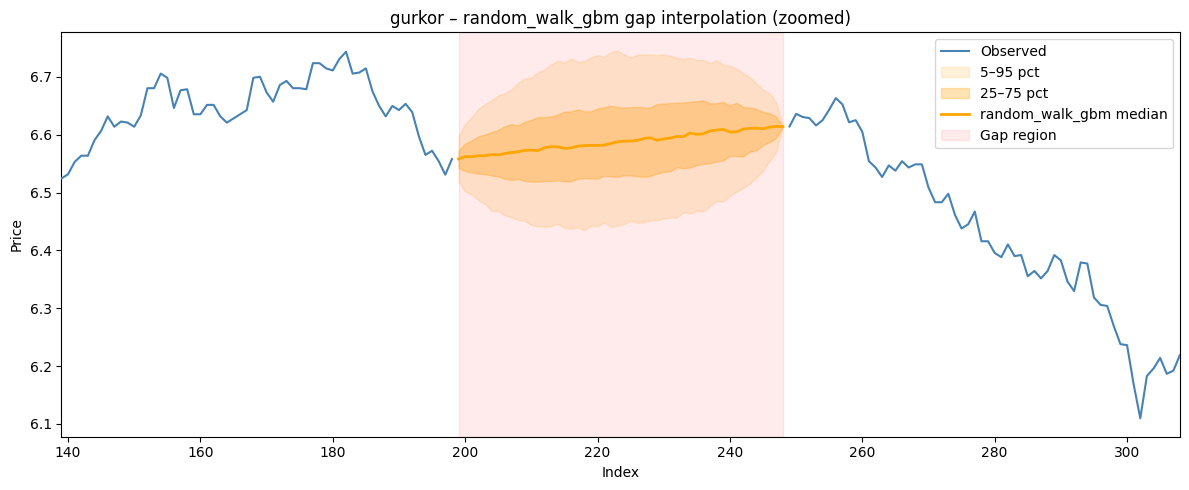

Drift: -0.000402  |  Volatility: 0.003912


In [12]:
gurkor_gap = internal_gaps[internal_gaps["series"] == "gurkor"].iloc[0]
gurkor_prices = prices["gurkor"]

rw = random_walk(
    price_series=gurkor_prices,
    start_day=gurkor_gap["start"],
    end_day=gurkor_gap["end"],
    random_seed=42,
)

plot_gap_interpolation(gurkor_prices, gurkor_gap["start"], gurkor_gap["end"], rw)
print(f"Drift: {rw['drift']:.6f}  |  Volatility: {rw['volatility']:.6f}")


In [13]:
from functools import partial
from tqdm.auto import tqdm

mean_cols = ["rmse", "mape_pct", "rmse_log", "coverage_90", "coverage_50", "mean_width_90_pct"]
summary_cols = ["rmse", "mape_pct", "mape_pct_max", "rmse_log", "coverage_90", "coverage_50", "mean_width_90_pct"]
methods = {
    "random_walk":       random_walk,
    "arima_bridge":      arima_bridge,
    "garch_bridge":      garch_bridge,
    "bootstrap_bridge":  bootstrap_bridge,
    "cross_series":      partial(cross_series_bridge, prices_df=prices),
    "cross_garch":       partial(cross_garch_bridge,  prices_df=prices),
}

backtest_jobs = [
    (series_name, method_name, method_fn)
    for series_name in internal_gaps["series"].tolist()
    for method_name, method_fn in methods.items()
]

rows = []
for series_name, method_name, method_fn in tqdm(backtest_jobs, desc="Backtesting models"):
    ps = prices[series_name]
    try:
        bt = backtest_interpolation(method_fn, ps, n_backtests=50, random_seed=42)
        means = bt[mean_cols].mean().to_dict()
        means["mape_pct_max"] = float(bt["mape_pct"].max())
    except Exception as exc:
        means = {c: np.nan for c in summary_cols}
        means["error"] = str(exc)
    means["series"] = series_name
    means["method"] = method_name
    rows.append(means)

all_results = (
    pd.DataFrame(rows)
    .set_index(["series", "method"])[summary_cols]
    .round(4)
)
display(all_results)

Backtesting models: 100%|██████████| 42/42 [01:00<00:00,  1.44s/it]


rmse  mape_pct  mape_pct_max  rmse_log  \
series       method                                                       
guitars      random_walk       0.2535    3.4669       11.1673    0.0409   
             arima_bridge      0.2543    3.4750       12.5819    0.0409   
             garch_bridge      0.2540    3.4545        9.5211    0.0408   
             bootstrap_bridge  0.2554    3.5003       11.4726    0.0412   
             cross_series      0.1605    2.1078        7.3594    0.0253   
             cross_garch       0.1644    2.1692        7.8515    0.0258   
gurkor       random_walk       0.1147    0.9634        2.6364    0.0115   
             arima_bridge      0.1133    0.9573        2.2935    0.0114   
             garch_bridge      0.1148    0.9714        2.9862    0.0116   
             bootstrap_bridge  0.1134    0.9505        2.5553    0.0113   
             cross_series      0.0845    0.7068        3.3570    0.0084   
             cross_garch       0.0811    0.6743        2.6119    0.0080   
slingshots   random_walk       0.1666    3.7118       15.3293    0.0439   
             arima_bridge      0.1653    3.7470       17.1516    0.0440   
             garch_bridge      0.1639    3.6696       13.1234    0.0435   
             bootstrap_bridge  0.1682    3.7534       15.6645    0.0443   
             cross_series      0.1228    2.6324       10.2978    0.0316   
             cross_garch       0.1185    2.5604       12.2108    0.0307   
stocks       random_walk       0.2197    3.4027        6.8644    0.0412   
             arima_bridge      0.2201    3.4187        6.8607    0.0414   
             garch_bridge      0.2195    3.4176        6.8528    0.0413   
             bootstrap_bridge  0.2191    3.3939        6.8334    0.0411   
             cross_series      0.2346    3.6568        7.2746    0.0441   
             cross_garch       0.2331    3.6261        7.3910    0.0437   
sugar        random_walk       0.1006    3.6798       14.2020    0.0436   
             arima_bridge      0.0963    3.5935       15.3988    0.0425   
             garch_bridge      0.0965    3.5779       14.8579    0.0425   
             bootstrap_bridge  0.1002    3.6606       14.1734    0.0435   
             cross_series      0.0925    3.3264       13.1724    0.0394   
             cross_garch       0.0900    3.2511       14.1236    0.0386   
tranquillity random_walk       0.4754    3.0039        7.6622    0.0362   
             arima_bridge      0.4680    2.9256        7.6221    0.0356   
             garch_bridge      0.4575    2.8587        7.5435    0.0348   
             bootstrap_bridge  0.4704    2.9790        7.8135    0.0358   
             cross_series      0.4441    2.7206        6.5863    0.0331   
             cross_garch       0.4352    2.6557        7.4450    0.0325   
water        random_walk       0.0613    0.7900        2.3141    0.0094   
             arima_bridge      0.0601    0.7793        2.3593    0.0093   
             garch_bridge      0.0600    0.7791        2.3351    0.0093   
             bootstrap_bridge  0.0618    0.7979        2.3535    0.0095   
             cross_series      0.0424    0.5497        1.2480    0.0065   
             cross_garch       0.0427    0.5556        1.4760    0.0066   

                               coverage_90  coverage_50  mean_width_90_pct  
series       method                                                         
guitars      random_walk            0.8648       0.4872            13.8323  
             arima_bridge           0.8359       0.4616            12.1724  
             garch_bridge           0.8567       0.4686            13.4027  
             bootstrap_bridge       0.8312       0.4220            12.0172  
             cross_series           0.8388       0.5136             8.5837  
             cross_garch            0.8656       0.5192             9.7286  
gurkor       random_walk            0.8812       0.4904             4.0905  
             arima_bridge           0.8

In [14]:
display(all_results.round(3))


rmse  mape_pct  mape_pct_max  rmse_log  \
series       method                                                      
guitars      random_walk       0.254     3.467        11.167     0.041   
             arima_bridge      0.254     3.475        12.582     0.041   
             garch_bridge      0.254     3.454         9.521     0.041   
             bootstrap_bridge  0.255     3.500        11.473     0.041   
             cross_series      0.160     2.108         7.359     0.025   
             cross_garch       0.164     2.169         7.852     0.026   
gurkor       random_walk       0.115     0.963         2.636     0.012   
             arima_bridge      0.113     0.957         2.294     0.011   
             garch_bridge      0.115     0.971         2.986     0.012   
             bootstrap_bridge  0.113     0.950         2.555     0.011   
             cross_series      0.084     0.707         3.357     0.008   
             cross_garch       0.081     0.674         2.612     0.008   
slingshots   random_walk       0.167     3.712        15.329     0.044   
             arima_bridge      0.165     3.747        17.152     0.044   
             garch_bridge      0.164     3.670        13.123     0.044   
             bootstrap_bridge  0.168     3.753        15.664     0.044   
             cross_series      0.123     2.632        10.298     0.032   
             cross_garch       0.118     2.560        12.211     0.031   
stocks       random_walk       0.220     3.403         6.864     0.041   
             arima_bridge      0.220     3.419         6.861     0.041   
             garch_bridge      0.220     3.418         6.853     0.041   
             bootstrap_bridge  0.219     3.394         6.833     0.041   
             cross_series      0.235     3.657         7.275     0.044   
             cross_garch       0.233     3.626         7.391     0.044   
sugar        random_walk       0.101     3.680        14.202     0.044   
             arima_bridge      0.096     3.594        15.399     0.042   
             garch_bridge      0.096     3.578        14.858     0.042   
             bootstrap_bridge  0.100     3.661        14.173     0.044   
             cross_series      0.092     3.326        13.172     0.039   
             cross_garch       0.090     3.251        14.124     0.039   
tranquillity random_walk       0.475     3.004         7.662     0.036   
             arima_bridge      0.468     2.926         7.622     0.036   
             garch_bridge      0.458     2.859         7.544     0.035   
             bootstrap_bridge  0.470     2.979         7.814     0.036   
             cross_series      0.444     2.721         6.586     0.033   
             cross_garch       0.435     2.656         7.445     0.032   
water        random_walk       0.061     0.790         2.314     0.009   
             arima_bridge      0.060     0.779         2.359     0.009   
             garch_bridge      0.060     0.779         2.335     0.009   
             bootstrap_bridge  0.062     0.798         2.354     0.010   
             cross_series      0.042     0.550         1.248     0.006   
             cross_garch       0.043     0.556         1.476     0.007   

                               coverage_90  coverage_50  mean_width_90_pct  
series       method                                                         
guitars      random_walk             0.865        0.487             13.832  
             arima_bridge            0.836        0.462             12.172  
             garch_bridge            0.857        0.469             13.403  
             bootstrap_bridge        0.831        0.422             12.017  
             cross_series            0.839        0.514              8.584  
             cross_garch             0.866        0.519              9.729  
gurkor       random_walk             0.881        0.490              4.090  
             arima_bridge            0.884        0.446              3.621  
     

In [15]:
# ── Cross-series lift over best single-series baseline ───────────────────────
single_methods = ["random_walk", "arima_bridge", "garch_bridge", "bootstrap_bridge"]
cross_methods  = ["cross_series", "cross_garch"]

m = all_results.index.get_level_values("method")
best_single = all_results[m.isin(single_methods)].groupby("series")["mape_pct"].min()
best_cross  = all_results[m.isin(cross_methods) ].groupby("series")["mape_pct"].min()

lift = pd.DataFrame({
    "best_single_mape": best_single,
    "best_cross_mape":  best_cross,
})
lift["mape_reduction_%"] = (
    (lift["best_single_mape"] - lift["best_cross_mape"]) / lift["best_single_mape"] * 100
).round(1)
print("=== Cross-series lift over best single-series method (MAPE) ===")
print(lift.sort_values("mape_reduction_%", ascending=False).to_string())

# ── cross_series vs cross_garch ───────────────────────────────────────────────
print("\n=== cross_series vs cross_garch (MAPE | coverage_90 | band_width_90%) ===")
cols = ["mape_pct", "coverage_90", "mean_width_90_pct"]
cv = all_results.loc[all_results.index.get_level_values("method").isin(cross_methods), cols]
cv = cv.unstack("method").swaplevel(axis=1).sort_index(axis=1)
cv[("winner", "mape")] = all_results["mape_pct"].unstack("method")[cross_methods].idxmin(axis=1)
print(cv.round(3).to_string())

=== Cross-series lift over best single-series method (MAPE) ===
              best_single_mape  best_cross_mape  mape_reduction_%
series                                                           
guitars                 3.4545           2.1078              39.0
slingshots              3.6696           2.5604              30.2
water                   0.7791           0.5497              29.4
gurkor                  0.9505           0.6743              29.1
sugar                   3.5779           3.2511               9.1
tranquillity            2.8587           2.6557               7.1
stocks                  3.3939           3.6261              -6.8

=== cross_series vs cross_garch (MAPE | coverage_90 | band_width_90%) ===
method       cross_garch                            cross_series                                   winner
             coverage_90 mape_pct mean_width_90_pct  coverage_90 mape_pct mean_width_90_pct          mape
series                                                 

In [16]:
# ── Single-series method ranking ─────────────────────────────────────────────
print("=== MAPE by single-series method (lower is better) ===")
single_mape = all_results.loc[
    all_results.index.get_level_values("method").isin(single_methods), "mape_pct"
].unstack("method")[single_methods]
single_mape["best"] = single_mape.idxmin(axis=1)
print(single_mape.round(4).to_string())

print("\nMethod wins (best MAPE count across series):")
print(single_mape["best"].value_counts().to_string())

# ── Bootstrap vs random_walk ──────────────────────────────────────────────────
print("\n=== Bootstrap vs random_walk delta MAPE (+ means bootstrap is worse) ===")
rw_mape   = all_results.xs("random_walk",       level="method")["mape_pct"]
boot_mape = all_results.xs("bootstrap_bridge",  level="method")["mape_pct"]
print((boot_mape - rw_mape).round(4).rename("bootstrap - random_walk").to_string())

=== MAPE by single-series method (lower is better) ===
method        random_walk  arima_bridge  garch_bridge  bootstrap_bridge              best
series                                                                                   
guitars            3.4669        3.4750        3.4545            3.5003      garch_bridge
gurkor             0.9634        0.9573        0.9714            0.9505  bootstrap_bridge
slingshots         3.7118        3.7470        3.6696            3.7534      garch_bridge
stocks             3.4027        3.4187        3.4176            3.3939  bootstrap_bridge
sugar              3.6798        3.5935        3.5779            3.6606      garch_bridge
tranquillity       3.0039        2.9256        2.8587            2.9790      garch_bridge
water              0.7900        0.7793        0.7791            0.7979      garch_bridge

Method wins (best MAPE count across series):
best
garch_bridge        5
bootstrap_bridge    2

=== Bootstrap vs random_walk delta MAPE

In [17]:
# ── Coverage and band-width efficiency ───────────────────────────────────────
print("=== Mean coverage and band width across all series ===")
cov_summary = all_results[["coverage_90", "coverage_50", "mean_width_90_pct"]].groupby("method").mean()
cov_summary = cov_summary.reindex(single_methods + cross_methods)
print(cov_summary.round(3).to_string())

# ── Accuracy vs band-width scatter summary ────────────────────────────────────
print("\n=== MAPE vs band-width: mean across all series ===")
efficiency = all_results[["mape_pct", "mean_width_90_pct"]].groupby("method").mean()
efficiency = efficiency.reindex(single_methods + cross_methods)
efficiency.columns = ["mean_mape", "mean_width_90%"]
print(efficiency.round(3).to_string())

# ── Summary conclusions ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("CONCLUSIONS")
print("=" * 65)

# Cross lift per series
for s in lift.sort_values("mape_reduction_%", ascending=False).index:
    r = lift.loc[s, "mape_reduction_%"]
    direction = "HURTS" if r < 0 else f"{r:.0f}% MAPE reduction"
    print(f"  {s:<14}: cross {direction}")

print()
cg_wins = (all_results["mape_pct"].unstack("method")["cross_garch"] <
           all_results["mape_pct"].unstack("method")["cross_series"]).sum()
print(f"  cross_garch beats cross_series in {cg_wins}/7 series by MAPE")

best_single_overall = single_mape["best"].value_counts()
print(f"  Best single-series method: {best_single_overall.index[0]} "
      f"({best_single_overall.iloc[0]}x)")

boot_worse = (boot_mape > rw_mape).sum()
print(f"  bootstrap_bridge is worse than random_walk in {boot_worse}/7 series")

rw_cov  = cov_summary.loc["random_walk",  "coverage_90"]
garch_cov = cov_summary.loc["garch_bridge", "coverage_90"]
boot_cov  = cov_summary.loc["bootstrap_bridge", "coverage_90"]
print(f"  Coverage_90 (mean): random_walk={rw_cov:.3f}  "
      f"garch={garch_cov:.3f}  bootstrap={boot_cov:.3f}  (target=0.90)")

cg_width  = cov_summary.loc["cross_garch",  "mean_width_90_pct"]
rw_width  = cov_summary.loc["random_walk",  "mean_width_90_pct"]
print(f"  Band width (90%, mean): cross_garch={cg_width:.1f}%  "
      f"random_walk={rw_width:.1f}%  — cross gives narrower bands AND better MAPE")

=== Mean coverage and band width across all series ===
                  coverage_90  coverage_50  mean_width_90_pct
method                                                       
random_walk             0.886        0.511             11.672
arima_bridge            0.868        0.474             10.196
garch_bridge            0.879        0.484             10.986
bootstrap_bridge        0.849        0.450             10.060
cross_series            0.847        0.479              8.538
cross_garch             0.890        0.512              9.640

=== MAPE vs band-width: mean across all series ===
                  mean_mape  mean_width_90%
method                                     
random_walk           2.717          11.672
arima_bridge          2.699          10.196
garch_bridge          2.676          10.986
bootstrap_bridge      2.719          10.060
cross_series          2.243           8.538
cross_garch           2.213           9.640

CONCLUSIONS
  guitars       : cross 39% MAPE

In [18]:
# ── Calibration window sensitivity sweep ─────────────────────────────────────
window_sizes = [20, 30, 45, 60, 90, 120]

cal_rows = []
for cal_win in tqdm(window_sizes, desc="Calibration windows"):
    for series_name in internal_gaps["series"].tolist():
        ps = prices[series_name]
        for method_name, method_fn in methods.items():
            try:
                bt = backtest_interpolation(
                    method_fn, ps,
                    n_backtests=50,
                    calibration_window=cal_win,
                    random_seed=42,
                )
                row = bt[mean_cols].mean().to_dict()
                row["mape_pct_max"] = float(bt["mape_pct"].max())
            except Exception:
                row = {c: np.nan for c in summary_cols}
            row["series"]     = series_name
            row["method"]     = method_name
            row["cal_window"] = cal_win
            cal_rows.append(row)

cal_results = (
    pd.DataFrame(cal_rows)
    .set_index(["cal_window", "series", "method"])
    .round(4)
)
display(cal_results["mape_pct"].unstack("method").round(3))

Calibration windows: 100%|██████████| 6/6 [05:35<00:00, 55.97s/it]


method                   arima_bridge  bootstrap_bridge  cross_garch  \
cal_window series                                                      
20         guitars              3.441             3.472        2.656   
           gurkor               0.978             0.957        0.685   
           slingshots           3.726             3.756        2.943   
           stocks               3.479             3.411        4.546   
           sugar                3.496             3.661        3.856   
           tranquillity         2.845             2.984        3.111   
           water                0.807             0.793        0.716   
30         guitars              3.436             3.463        2.434   
           gurkor               0.973             0.955        0.706   
           slingshots           3.740             3.753        2.579   
           stocks               3.416             3.415        4.127   
           sugar                3.537             3.646        3.564   
           tranquillity         2.893             2.984        2.980   
           water                0.784             0.796        0.672   
45         guitars              3.468             3.493        2.352   
           gurkor               0.960             0.956        0.670   
           slingshots           3.725             3.748        2.513   
           stocks               3.422             3.416        3.871   
           sugar                3.549             3.645        3.271   
           tranquillity         2.905             2.986        2.832   
           water                0.779             0.795        0.596   
60         guitars              3.488             3.501        2.175   
           gurkor               0.959             0.955        0.682   
           slingshots           3.746             3.750        2.578   
           stocks               3.442             3.398        3.616   
           sugar                3.558             3.653        3.257   
           tranquillity         2.896             2.994        2.636   
           water                0.780             0.799        0.556   
90         guitars              3.487             3.480        2.079   
           gurkor               0.954             0.958        0.688   
           slingshots           3.785             3.746        2.649   
           stocks               3.420             3.408        3.542   
           sugar                3.616             3.660        3.191   
           tranquillity         2.905             2.981        2.687   
           water                0.781             0.794        0.543   
120        guitars              3.479             3.486        2.093   
           gurkor               0.959             0.958        0.685   
           slingshots           3.794             3.740        2.660   
           stocks               3.421             3.398        3.510   
           sugar                3.593             3.655        3.188   
           tranquillity         2.905             2.977        2.610   
           water                0.777             0.795        0.522   

method                   cross_series  garch_bridge  random_walk  
cal_window series                                                 
20         guitars              2.399           NaN        3.476  
           gurkor               0.694           NaN        0.961  
           slingshots           2.960           NaN        3.758  
           stocks               4.209           NaN        3.418  
           sugar                3.816           NaN        3.651  
           tranquillity         2.970           NaN        3.006  
           water                0.673           NaN        0.796  
30         guitars              2.332         3.460        3.484  
           gurkor               0.732         0.976        0.964  
           slingshots           2.726         3.674        3.771  
           stocks          

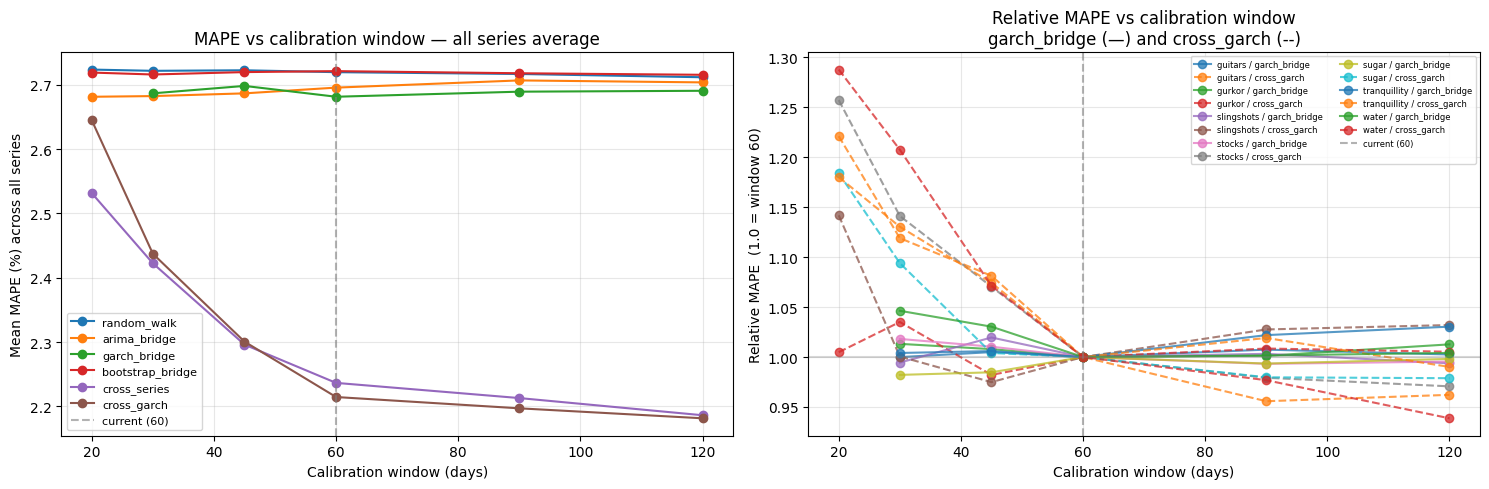

=== Optimal calibration window per method (lowest mean MAPE across series) ===
  random_walk         : best window = 120d  (MAPE 2.712%  vs 2.720% at 60d,  Δ=+0.3%)
  arima_bridge        : best window =  20d  (MAPE 2.682%  vs 2.696% at 60d,  Δ=+0.5%)
  garch_bridge        : best window =  60d  (MAPE 2.682%  vs 2.682% at 60d,  Δ=+0.0%)
  bootstrap_bridge    : best window = 120d  (MAPE 2.716%  vs 2.721% at 60d,  Δ=+0.2%)
  cross_series        : best window = 120d  (MAPE 2.186%  vs 2.236% at 60d,  Δ=+2.2%)
  cross_garch         : best window = 120d  (MAPE 2.181%  vs 2.214% at 60d,  Δ=+1.5%)


In [19]:
# ── Plot: MAPE vs calibration window ─────────────────────────────────────────
method_order  = list(methods.keys())
series_list   = internal_gaps["series"].tolist()
colors        = plt.rcParams["axes.prop_cycle"].by_key()["color"]
method_colors = {m: colors[i % len(colors)] for i, m in enumerate(method_order)}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: mean MAPE across all series per method ──────────────────────────────
ax = axes[0]
mean_mape = cal_results["mape_pct"].groupby(["cal_window", "method"]).mean().unstack("method")
for method in method_order:
    if method in mean_mape.columns:
        ax.plot(mean_mape.index, mean_mape[method],
                marker="o", label=method, color=method_colors[method])
ax.axvline(60, ls="--", color="gray", alpha=0.6, label="current (60)")
ax.set_xlabel("Calibration window (days)")
ax.set_ylabel("Mean MAPE (%) across all series")
ax.set_title("MAPE vs calibration window — all series average")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Right: relative MAPE per series (normalised to window=60) ────────────────
# Show the two best methods only to keep it readable
focus_methods = ["garch_bridge", "cross_garch"]
ax = axes[1]
linestyles = ["-", "--"]
for series_name in series_list:
    for j, method in enumerate(focus_methods):
        try:
            data = cal_results["mape_pct"].xs(
                (series_name, method), level=("series", "method")
            )
            baseline = data.loc[60]
            if baseline > 0:
                ax.plot(
                    data.index,
                    data / baseline,
                    marker="o",
                    linestyle=linestyles[j],
                    alpha=0.75,
                    label=f"{series_name} / {method}",
                )
        except KeyError:
            pass
ax.axvline(60, ls="--", color="gray", alpha=0.6, label="current (60)")
ax.axhline(1.0,  ls="-",  color="gray", alpha=0.3)
ax.set_xlabel("Calibration window (days)")
ax.set_ylabel("Relative MAPE  (1.0 = window 60)")
ax.set_title("Relative MAPE vs calibration window\ngarch_bridge (—) and cross_garch (--)")
ax.legend(fontsize=6, ncol=2, loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Numeric summary: which window minimises mean MAPE per method ──────────────
print("=== Optimal calibration window per method (lowest mean MAPE across series) ===")
for method in method_order:
    if method in mean_mape.columns:
        best_win = int(mean_mape[method].idxmin())
        best_val = mean_mape[method].min()
        val_at60 = mean_mape[method].loc[60]
        gain     = (val_at60 - best_val) / val_at60 * 100
        print(f"  {method:<20}: best window = {best_win:>3}d  "
              f"(MAPE {best_val:.3f}%  vs {val_at60:.3f}% at 60d,  Δ={gain:+.1f}%)")